# Racing Telemetry — Feature Engineering

**Goal:** Transform raw telemetry signals into meaningful features for modeling and analysis.  
**Input:** `telemetry-rio-5-laps.csv` (94,519 samples × 73 raw columns)  
**Output:**
- `features_engineered.parquet` — all samples with ~40 engineered features
- `features_per_lap.csv` — one row per lap (4 rows) with aggregated metrics
- `features_per_corner.csv` — one row per corner per lap with corner-level statistics

## Feature Groups
1. Normalized inputs (throttle, brake, steer → 0–1 / –1 to 1)
2. Track distance & lap progress
3. Track section classification (STRAIGHT / BRAKING / CORNER / ACCELERATION)
4. Corner detection & cataloging
5. Vehicle dynamics (speed delta, understeer index, wheel spin index)
6. Tire features (temperature averages, imbalances)
7. Rolling window features (1-second window)
8. Lap-delta features (time gap vs best lap at same track position)
9. Lap-level aggregated features

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.signal import find_peaks
import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f0f0f', 'axes.facecolor': '#1a1a1a',
    'axes.edgecolor': '#444444', 'axes.labelcolor': '#cccccc',
    'xtick.color': '#888888', 'ytick.color': '#888888',
    'text.color': '#cccccc', 'grid.color': '#2a2a2a',
    'grid.linewidth': 0.6, 'axes.titlesize': 13,
    'legend.facecolor': '#1a1a1a', 'legend.edgecolor': '#444444',
    'figure.dpi': 110,
})

LAP_COLORS = {1: '#00d4ff', 2: '#ff6b35', 3: '#7fff00', 4: '#ff00aa'}
SECTION_COLORS = {
    'STRAIGHT':     '#00d4ff',
    'BRAKING':      '#ff3333',
    'CORNER':       '#ffaa00',
    'ACCELERATION': '#7fff00',
}

BEST_LAP = 4
TRACK_LENGTH_M = 6163.5   # mean of the 4 laps
SAMPLE_RATE_HZ = 120

print('Setup complete.')

Setup complete.


## 2. Load Data

In [2]:
df_raw = pd.read_csv('telemetry-rio-5-laps.csv', index_col=0)

# Boolean columns
for col in [c for c in df_raw.columns if 'rumble' in c]:
    df_raw[col] = df_raw[col].map({'True': True, 'False': False})

# Work only with racing laps
df = df_raw[df_raw['lap_number'] >= 1].copy().reset_index(drop=True)

print(f'Racing laps rows: {len(df):,}')
print(f'Laps: {sorted(df["lap_number"].unique())}')

Racing laps rows: 75,090
Laps: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


## 3. Group 1 — Normalized Inputs

In [3]:
# Throttle and brake: 0–255 → 0.0–1.0
df['throttle_norm'] = df['acceleration'] / 255.0
df['brake_norm']    = df['brake']        / 255.0

# Steer: –127–127 → –1.0–1.0
df['steer_norm'] = df['steer'] / 127.0

# Speed in km/h
df['speed_kmh'] = df['speed'] * 3.6

# Acceleration in g (lateral and longitudinal)
df['g_lateral']      = df['acceleration_x'] / 9.81
df['g_longitudinal'] = df['acceleration_z'] / 9.81

# Power and torque (positive only — on-power moments)
df['power_kw'] = df['power'] / 1000.0

print('Group 1 — Normalized inputs: done')
print(f"  throttle_norm: [{df['throttle_norm'].min():.2f}, {df['throttle_norm'].max():.2f}]")
print(f"  steer_norm:    [{df['steer_norm'].min():.2f}, {df['steer_norm'].max():.2f}]")

Group 1 — Normalized inputs: done
  throttle_norm: [0.00, 1.00]
  steer_norm:    [-1.00, 1.00]


## 4. Group 2 — Track Distance & Lap Progress

In [4]:
# distance_traveled resets to 0 at the start of each lap
# We compute it as offset from the lap's first sample
lap_start_dist = df.groupby('lap_number')['distance_traveled'].transform('first')
df['lap_dist_m'] = df['distance_traveled'] - lap_start_dist

# Lap length per lap (total meters driven)
lap_lengths = df.groupby('lap_number')['lap_dist_m'].transform('max')
df['lap_dist_pct'] = (df['lap_dist_m'] / lap_lengths * 100).clip(0, 100)

# Discretize into 200 equal-width bins (0.5% each) — used for delta-time interpolation
df['lap_bin_200'] = pd.cut(df['lap_dist_pct'], bins=200,
                            labels=False, include_lowest=True)

print('Group 2 — Track distance: done')
print(df.groupby('lap_number')[['lap_dist_m', 'lap_dist_pct']].max().round(1))

Group 2 — Track distance: done
            lap_dist_m  lap_dist_pct
lap_number                          
1               6163.6         100.0
2               6163.4         100.0
3               6163.5         100.0
4               6163.4         100.0


## 5. Group 3 — Track Section Classification

Four mutually-exclusive sections assigned with a simple priority rule:

| Section | Rule |
|---|---|
| **BRAKING** | brake > 10% |
| **CORNER** | `\|lateral G\|` > 0.5 g AND brake ≤ 10% |
| **ACCELERATION** | throttle > 60% AND `\|lateral G\|` ≤ 0.5 g AND brake ≤ 10% |
| **STRAIGHT** | everything else |

In [5]:
def classify_section(row):
    if row['brake_norm'] > 0.10:
        return 'BRAKING'
    if abs(row['g_lateral']) > 0.5 and row['brake_norm'] <= 0.10:
        return 'CORNER'
    if row['throttle_norm'] > 0.60 and abs(row['g_lateral']) <= 0.5:
        return 'ACCELERATION'
    return 'STRAIGHT'

df['track_section'] = df.apply(classify_section, axis=1)

# Section distribution
sec_pct = df['track_section'].value_counts(normalize=True) * 100
print('Track section distribution (% of samples):')
for sec, pct in sec_pct.items():
    print(f'  {sec:<14}: {pct:5.1f}%')

Track section distribution (% of samples):
  CORNER        :  47.2%
  ACCELERATION  :  34.8%
  BRAKING       :  15.7%
  STRAIGHT      :   2.3%


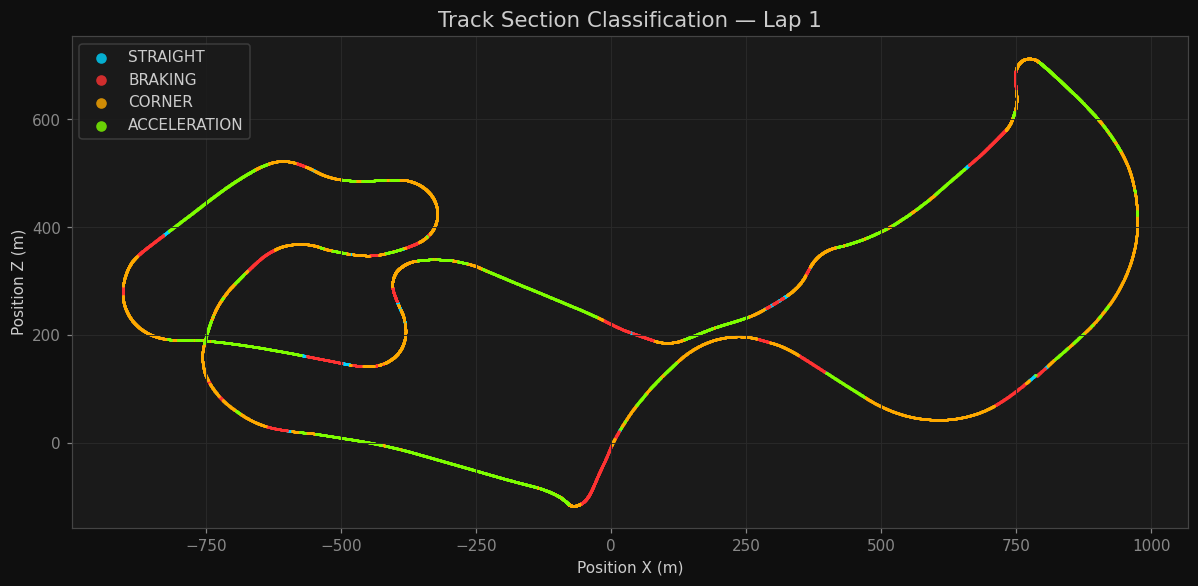

In [6]:
# Visualize sections on the track map
lap1 = df[df['lap_number'] == 1]

fig, ax = plt.subplots(figsize=(11, 9))
for section, color in SECTION_COLORS.items():
    mask = lap1['track_section'] == section
    ax.scatter(lap1.loc[mask, 'position_x'], lap1.loc[mask, 'position_z'],
               s=3, color=color, alpha=0.8, label=section, linewidths=0)

ax.set_title('Track Section Classification — Lap 1', fontsize=14)
ax.set_xlabel('Position X (m)')
ax.set_ylabel('Position Z (m)')
ax.set_aspect('equal')
ax.legend(fontsize=10, markerscale=4)
ax.grid(True)
plt.tight_layout()
plt.savefig('track_sections.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## 6. Group 4 — Corner Detection & Cataloging

Corners are identified as **local minima in the speed trace** within each lap.  
Each detected apex receives a corner ID; we then extract entry/apex/exit metrics.

In [7]:
def detect_corners(lap_df, min_distance_samples=60, min_prominence_kmh=10):
    """
    Returns a list of (sample_index, apex_speed_kmh) for every corner apex.
    min_distance_samples: minimum gap between corners (~0.5 s at 120 Hz)
    min_prominence_kmh:   minimum speed drop to count as a real corner
    """
    speed = lap_df['speed_kmh'].values
    # find_peaks on -speed == find valleys in speed
    peaks, props = find_peaks(
        -speed,
        distance=min_distance_samples,
        prominence=min_prominence_kmh
    )
    return peaks  # indices within the lap DataFrame


# Detect corners in lap 1 as reference
lap1_df = df[df['lap_number'] == 1].reset_index(drop=True)
corner_indices = detect_corners(lap1_df)

print(f'Corners detected in Lap 1: {len(corner_indices)}')
for i, idx in enumerate(corner_indices):
    spd = lap1_df.loc[idx, 'speed_kmh']
    dist = lap1_df.loc[idx, 'lap_dist_m']
    print(f'  C{i+1:02d}  apex @ {dist:5.0f} m  |  apex speed: {spd:.1f} km/h')

Corners detected in Lap 1: 15
  C01  apex @   129 m  |  apex speed: 166.1 km/h
  C02  apex @   597 m  |  apex speed: 142.9 km/h
  C03  apex @  1096 m  |  apex speed: 36.2 km/h
  C04  apex @  1884 m  |  apex speed: 118.5 km/h
  C05  apex @  2142 m  |  apex speed: 116.5 km/h
  C06  apex @  2326 m  |  apex speed: 125.6 km/h
  C07  apex @  2429 m  |  apex speed: 91.1 km/h
  C08  apex @  2818 m  |  apex speed: 114.1 km/h
  C09  apex @  3227 m  |  apex speed: 102.6 km/h
  C10  apex @  3750 m  |  apex speed: 93.0 km/h
  C11  apex @  3938 m  |  apex speed: 70.7 km/h
  C12  apex @  4490 m  |  apex speed: 105.0 km/h
  C13  apex @  4830 m  |  apex speed: 100.4 km/h
  C14  apex @  5261 m  |  apex speed: 91.9 km/h
  C15  apex @  5404 m  |  apex speed: 60.1 km/h


In [8]:
# Assign corner_id to every sample (–1 = not in a corner window)
# Window: ±60 samples (~0.5 s) around each apex
CORNER_WINDOW = 60

df['corner_id'] = -1

all_corner_records = []

for lap in sorted(df['lap_number'].unique()):
    lap_mask = df['lap_number'] == lap
    lap_df   = df[lap_mask].reset_index(drop=True)
    global_indices = df.index[lap_mask].tolist()

    apex_idxs = detect_corners(lap_df)

    for corner_num, apex in enumerate(apex_idxs):
        cid = int(f'{lap}{corner_num+1:02d}')  # e.g. lap=1, corner=3 → 103

        # Label samples within the window
        start = max(0, apex - CORNER_WINDOW)
        end   = min(len(lap_df) - 1, apex + CORNER_WINDOW)
        window_global = [global_indices[i] for i in range(start, end + 1)]
        df.loc[window_global, 'corner_id'] = cid

        # Entry: first sample of window; Apex: detected minimum; Exit: last sample
        entry_row = lap_df.iloc[start]
        apex_row  = lap_df.iloc[apex]
        exit_row  = lap_df.iloc[end]

        all_corner_records.append({
            'lap':            lap,
            'corner_num':     corner_num + 1,
            'corner_id':      cid,
            'dist_m':         apex_row['lap_dist_m'],
            'entry_speed_kmh': entry_row['speed_kmh'],
            'apex_speed_kmh':  apex_row['speed_kmh'],
            'exit_speed_kmh':  exit_row['speed_kmh'],
            'max_lat_g':       lap_df.iloc[start:end+1]['g_lateral'].abs().max(),
            'min_brake_entry': entry_row['brake_norm'],
            'max_throttle_exit': exit_row['throttle_norm'],
            'speed_loss_kmh':  entry_row['speed_kmh'] - apex_row['speed_kmh'],
        })

df_corners = pd.DataFrame(all_corner_records)
print(f'Total corner records (all laps): {len(df_corners)}')
print(df_corners[df_corners['lap'] == 1][['corner_num','dist_m','entry_speed_kmh',
                                           'apex_speed_kmh','exit_speed_kmh',
                                           'max_lat_g','speed_loss_kmh']].round(1).to_string(index=False))

Total corner records (all laps): 56
 corner_num  dist_m  entry_speed_kmh  apex_speed_kmh  exit_speed_kmh  max_lat_g  speed_loss_kmh
          1   129.1            169.2           166.1           170.3        1.3             3.0
          2   596.5            151.2           142.9           144.3        1.3             8.3
          3  1096.3             46.1            36.2            43.2        1.4             9.9
          4  1884.4            126.0           118.5           123.8        1.5             7.5
          5  2142.1            120.5           116.5           119.3        1.4             4.0
          6  2325.8            136.3           125.6           132.2        1.4            10.7
          7  2428.8             98.8            91.1            92.5        1.5             7.7
          8  2818.0            119.7           114.1           119.6        1.7             5.6
          9  3226.5            106.5           102.6           107.3        1.3             3.9
    

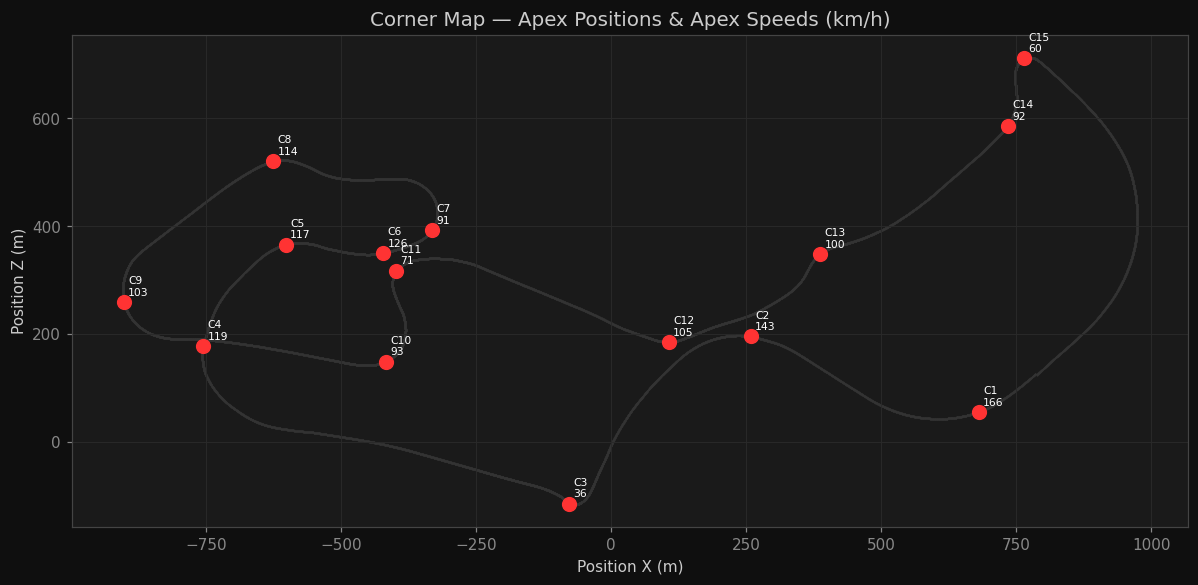

In [9]:
# Corner map — apex positions colored by apex speed
fig, ax = plt.subplots(figsize=(11, 9))

# Track base
ax.scatter(lap1_df['position_x'], lap1_df['position_z'],
           s=1.5, color='#333333', linewidths=0)

# Apex markers
c1_corners = df_corners[df_corners['lap'] == 1]
for _, row in c1_corners.iterrows():
    apex_idx = int(detect_corners(lap1_df)[int(row['corner_num']) - 1])
    px = lap1_df.loc[apex_idx, 'position_x']
    pz = lap1_df.loc[apex_idx, 'position_z']
    ax.scatter(px, pz, s=80, color='#ff3333', zorder=5)
    ax.text(px + 8, pz + 8, f"C{int(row['corner_num'])}\n{row['apex_speed_kmh']:.0f}",
            fontsize=7, color='white', va='bottom')

ax.set_title('Corner Map — Apex Positions & Apex Speeds (km/h)', fontsize=13)
ax.set_xlabel('Position X (m)')
ax.set_ylabel('Position Z (m)')
ax.set_aspect('equal')
ax.grid(True)
plt.tight_layout()
plt.savefig('corner_map.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

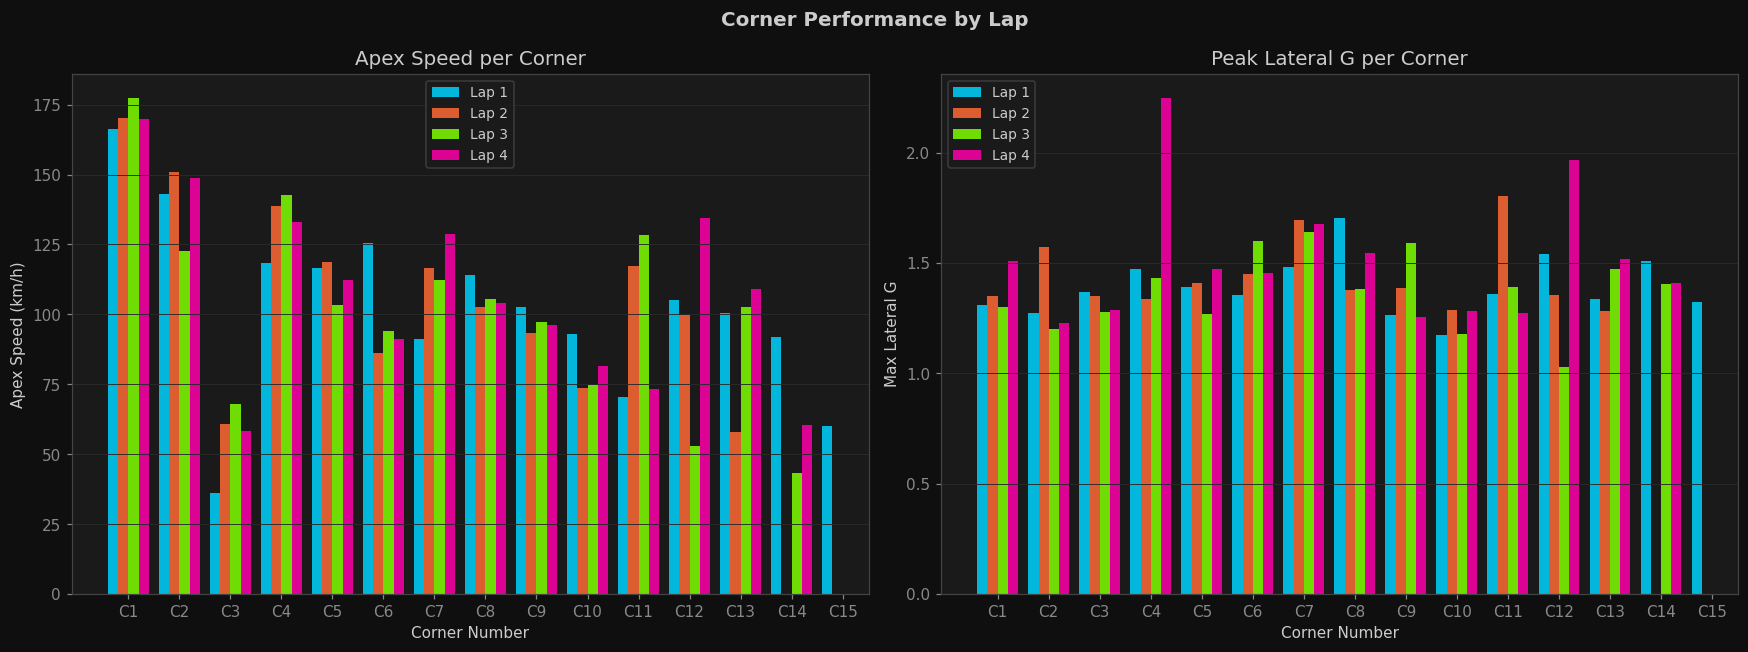

In [10]:
# Corner performance across laps
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Corner Performance by Lap', fontsize=13, fontweight='bold')

# Align corners across laps by corner_num
n_corners = df_corners[df_corners['lap'] == 1]['corner_num'].max()
x_pos = np.arange(1, n_corners + 1)
width = 0.2

ax = axes[0]
for i, lap in enumerate(sorted(df_corners['lap'].unique())):
    lap_c = df_corners[df_corners['lap'] == lap].set_index('corner_num')
    speeds = [lap_c.loc[c, 'apex_speed_kmh'] if c in lap_c.index else np.nan
              for c in range(1, n_corners + 1)]
    ax.bar(x_pos + i * width, speeds, width=width,
           color=LAP_COLORS[lap], alpha=0.85, label=f'Lap {lap}')
ax.set_xlabel('Corner Number')
ax.set_ylabel('Apex Speed (km/h)')
ax.set_title('Apex Speed per Corner')
ax.set_xticks(x_pos + width * 1.5)
ax.set_xticklabels([f'C{c}' for c in range(1, n_corners + 1)])
ax.legend(fontsize=9)
ax.grid(True, axis='y')

ax = axes[1]
for i, lap in enumerate(sorted(df_corners['lap'].unique())):
    lap_c = df_corners[df_corners['lap'] == lap].set_index('corner_num')
    lat_g = [lap_c.loc[c, 'max_lat_g'] if c in lap_c.index else np.nan
              for c in range(1, n_corners + 1)]
    ax.bar(x_pos + i * width, lat_g, width=width,
           color=LAP_COLORS[lap], alpha=0.85, label=f'Lap {lap}')
ax.set_xlabel('Corner Number')
ax.set_ylabel('Max Lateral G')
ax.set_title('Peak Lateral G per Corner')
ax.set_xticks(x_pos + width * 1.5)
ax.set_xticklabels([f'C{c}' for c in range(1, n_corners + 1)])
ax.legend(fontsize=9)
ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('corner_performance.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## 7. Group 5 — Vehicle Dynamics Features

In [11]:
# ── Speed delta (km/h per second) ────────────────────────────────────────────
# dt in seconds from since_last_ns
df['dt_s'] = df['since_last_ns'] / 1e9
df['speed_delta_kmh_s'] = df['speed_kmh'].diff() / df['dt_s'].replace(0, np.nan)
df['speed_delta_kmh_s'] = df['speed_delta_kmh_s'].clip(-500, 500)  # remove artefacts at lap boundary
# Zero out lap boundaries
lap_boundary = df['lap_number'] != df['lap_number'].shift(1)
df.loc[lap_boundary, 'speed_delta_kmh_s'] = 0.0

# ── Understeer index ─────────────────────────────────────────────────────────
# Positive = understeer (front slips more), Negative = oversteer (rear slips more)
df['front_slip_avg'] = df[['tire_slip_angle_front_left',
                            'tire_slip_angle_front_right']].abs().mean(axis=1)
df['rear_slip_avg']  = df[['tire_slip_angle_rear_left',
                            'tire_slip_angle_rear_right']].abs().mean(axis=1)
df['understeer_index'] = df['front_slip_avg'] - df['rear_slip_avg']

# ── Wheel spin index ─────────────────────────────────────────────────────────
# Rear wheel speed (rad/s) vs front wheel speed — positive = rear faster (spin)
df['front_wheel_speed_avg'] = df[['wheel_rotation_speed_front_left',
                                    'wheel_rotation_speed_front_right']].mean(axis=1)
df['rear_wheel_speed_avg']  = df[['wheel_rotation_speed_rear_left',
                                    'wheel_rotation_speed_rear_right']].mean(axis=1)

safe_front = df['front_wheel_speed_avg'].replace(0, np.nan)
df['wheel_spin_index'] = (df['rear_wheel_speed_avg'] - df['front_wheel_speed_avg']) / safe_front

# ── Wheel lock index ─────────────────────────────────────────────────────────
# Difference between actual front wheel speed and expected speed from vehicle velocity
# positive = wheels spinning faster than car → lock not applicable here; 
# negative wheel_spin_index while braking = front locking
df['wheel_lock_flag'] = (
    (df['brake_norm'] > 0.3) & (df['wheel_spin_index'] < -0.05)
).astype(int)

# ── Combined slip average ─────────────────────────────────────────────────────
slip_cols = ['tire_combined_slip_front_left', 'tire_combined_slip_front_right',
             'tire_combined_slip_rear_left',  'tire_combined_slip_rear_right']
df['combined_slip_avg'] = df[slip_cols].mean(axis=1)

print('Group 5 — Vehicle dynamics: done')
print(f"  understeer_index range: [{df['understeer_index'].min():.4f}, {df['understeer_index'].max():.4f}]")
print(f"  wheel_spin_index range: [{df['wheel_spin_index'].min():.4f}, {df['wheel_spin_index'].max():.4f}]")
print(f"  wheel_lock_flag: {df['wheel_lock_flag'].sum()} samples ({df['wheel_lock_flag'].mean()*100:.1f}%)")

Group 5 — Vehicle dynamics: done
  understeer_index range: [-6.9874, 1.4693]
  wheel_spin_index range: [-0.5602, 0.8225]
  wheel_lock_flag: 3360 samples (4.5%)


## 8. Group 6 — Tire Features

In [12]:
temp_cols = ['tire_temp_front_left', 'tire_temp_front_right',
             'tire_temp_rear_left',  'tire_temp_rear_right']

# Average temperature
df['tire_temp_avg'] = df[temp_cols].mean(axis=1)

# Front-rear imbalance (positive = front hotter)
df['tire_temp_fr_delta'] = (
    df[['tire_temp_front_left', 'tire_temp_front_right']].mean(axis=1) -
    df[['tire_temp_rear_left',  'tire_temp_rear_right']].mean(axis=1)
)

# Left-right imbalance (positive = left hotter)
df['tire_temp_lr_delta'] = (
    df[['tire_temp_front_left', 'tire_temp_rear_left']].mean(axis=1) -
    df[['tire_temp_front_right','tire_temp_rear_right']].mean(axis=1)
)

# Cumulative tire temp increase per lap (proxy for degradation)
df['tire_temp_deg_proxy'] = df.groupby('lap_number')['tire_temp_avg'].transform(
    lambda s: s - s.iloc[0]
)

print('Group 6 — Tire features: done')
print(f"  tire_temp_avg:      {df['tire_temp_avg'].mean():.2f} °C")
print(f"  tire_temp_fr_delta: {df['tire_temp_fr_delta'].mean():.3f} °C (mean)")
print(f"  tire_temp_lr_delta: {df['tire_temp_lr_delta'].mean():.3f} °C (mean)")

Group 6 — Tire features: done
  tire_temp_avg:      213.31 °C
  tire_temp_fr_delta: 0.328 °C (mean)
  tire_temp_lr_delta: 0.034 °C (mean)


## 9. Group 7 — Rolling Window Features (1-second window)

At ~120 Hz, 1 second ≈ 120 samples.

In [13]:
WINDOW = 120  # samples ≈ 1 second

def lap_rolling(series, lap_col, window, func='mean'):
    """Apply rolling within each lap independently to avoid bleeding across lap boundaries."""
    result = pd.Series(index=series.index, dtype=float)
    for lap in lap_col.unique():
        mask = lap_col == lap
        s = series[mask]
        roll = s.rolling(window, min_periods=1)
        result[mask] = getattr(roll, func)()
    return result

df['roll_speed_mean']    = lap_rolling(df['speed_kmh'],    df['lap_number'], WINDOW, 'mean')
df['roll_speed_std']     = lap_rolling(df['speed_kmh'],    df['lap_number'], WINDOW, 'std').fillna(0)
df['roll_throttle_mean'] = lap_rolling(df['throttle_norm'],df['lap_number'], WINDOW, 'mean')
df['roll_brake_max']     = lap_rolling(df['brake_norm'],   df['lap_number'], WINDOW, 'max')
df['roll_lat_g_max']     = lap_rolling(df['g_lateral'].abs(), df['lap_number'], WINDOW, 'max')
df['roll_slip_mean']     = lap_rolling(df['combined_slip_avg'], df['lap_number'], WINDOW, 'mean')

print('Group 7 — Rolling features (1 s window): done')
print(df[['roll_speed_mean','roll_speed_std','roll_throttle_mean',
          'roll_brake_max','roll_lat_g_max','roll_slip_mean']].describe().round(3))

Group 7 — Rolling features (1 s window): done
       roll_speed_mean  roll_speed_std  roll_throttle_mean  roll_brake_max  \
count        75090.000       75090.000           75090.000       75090.000   
mean           140.280           3.790               0.680           0.218   
std             38.034           2.804               0.373           0.369   
min             39.941           0.000               0.000           0.000   
25%            110.471           1.865               0.365           0.000   
50%            141.770           3.092               0.880           0.000   
75%            171.566           4.646               1.000           0.412   
max            224.579          16.510               1.000           1.000   

       roll_lat_g_max  roll_slip_mean  
count       75090.000       75090.000  
mean            1.042           0.546  
std             0.516           0.487  
min             0.009           0.019  
25%             0.607           0.171  
50%        

## 10. Group 8 — Lap-Delta Feature (Gap vs Best Lap)

For each sample in laps 1, 2, and 3 we compute **how many seconds behind the best lap (lap 4)** the car is at the same track position.  
A positive delta means the lap is slower at that point; negative means it is ahead.

In [14]:
# Build best-lap reference: median current_lap_time at each lap_bin_200
best_lap_df = df[df['lap_number'] == BEST_LAP][['lap_bin_200', 'current_lap_time']].copy()
best_lap_ref = best_lap_df.groupby('lap_bin_200')['current_lap_time'].median()

# Map reference time to every sample
df['best_lap_ref_time'] = df['lap_bin_200'].map(best_lap_ref)

# Delta = current lap time – best lap time at the same track bin
# For the best lap itself this will be ~0 by construction
df['delta_time_s'] = df['current_lap_time'] - df['best_lap_ref_time']

print('Group 8 — Lap-delta feature: done')
for lap in sorted(df['lap_number'].unique()):
    mean_delta = df[df['lap_number'] == lap]['delta_time_s'].mean()
    max_delta  = df[df['lap_number'] == lap]['delta_time_s'].max()
    print(f'  Lap {lap} — mean delta: {mean_delta:+.2f} s  |  max delta: {max_delta:+.2f} s')

Group 8 — Lap-delta feature: done
  Lap 1 — mean delta: +2.72 s  |  max delta: +5.86 s
  Lap 2 — mean delta: +1.88 s  |  max delta: +4.17 s
  Lap 3 — mean delta: +2.19 s  |  max delta: +6.20 s
  Lap 4 — mean delta: -0.00 s  |  max delta: +0.77 s


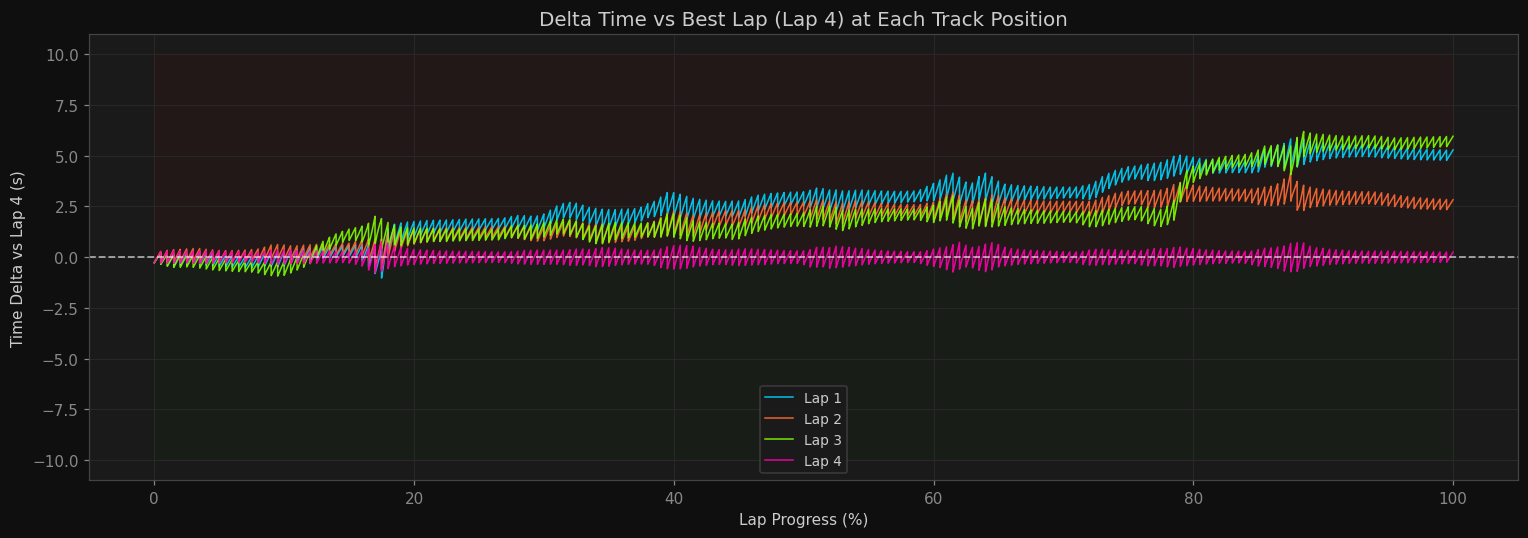

In [15]:
# Visualize delta-time evolution per lap
fig, ax = plt.subplots(figsize=(14, 5))

for lap in sorted(df['lap_number'].unique()):
    ldf = df[df['lap_number'] == lap]
    ax.plot(ldf['lap_dist_pct'], ldf['delta_time_s'],
            color=LAP_COLORS[lap], lw=1, alpha=0.9, label=f'Lap {lap}')

ax.axhline(0, color='white', lw=1.2, linestyle='--', alpha=0.6)
ax.fill_between([0, 100], 0, 10, alpha=0.04, color='red')
ax.fill_between([0, 100], -10, 0, alpha=0.04, color='green')
ax.set_xlabel('Lap Progress (%)')
ax.set_ylabel('Time Delta vs Lap 4 (s)')
ax.set_title('Delta Time vs Best Lap (Lap 4) at Each Track Position')
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.savefig('delta_time.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## 11. Group 9 — Lap-Level Aggregated Features

In [16]:
lap_agg = df.groupby('lap_number').agg(
    # Times
    lap_time_s             = ('current_lap_time', 'max'),

    # Speed
    speed_avg_kmh          = ('speed_kmh', 'mean'),
    speed_max_kmh          = ('speed_kmh', 'max'),
    speed_min_kmh          = ('speed_kmh', 'min'),
    speed_std_kmh          = ('speed_kmh', 'std'),

    # Distance
    total_dist_m           = ('lap_dist_m', 'max'),

    # Driver inputs
    throttle_mean          = ('throttle_norm', 'mean'),
    pct_full_throttle      = ('throttle_norm', lambda x: (x > 0.95).mean() * 100),
    pct_braking            = ('brake_norm',    lambda x: (x > 0.10).mean() * 100),
    pct_coasting           = ('throttle_norm', lambda x: ((x < 0.05) & (df.loc[x.index,'brake_norm'] < 0.05)).mean() * 100),
    pct_throttle_brake_overlap = ('throttle_norm', lambda x: ((x > 0.05) & (df.loc[x.index,'brake_norm'] > 0.05)).mean() * 100),

    # G-forces
    max_lat_g              = ('g_lateral', lambda x: x.abs().max()),
    avg_lat_g              = ('g_lateral', lambda x: x.abs().mean()),
    max_long_g_accel       = ('g_longitudinal', 'max'),
    max_long_g_brake       = ('g_longitudinal', 'min'),

    # Tires
    tire_temp_avg_c        = ('tire_temp_avg', 'mean'),
    tire_temp_max_c        = ('tire_temp_avg', 'max'),
    tire_temp_delta_c      = ('tire_temp_avg', lambda x: x.iloc[-1] - x.iloc[0]),
    combined_slip_avg      = ('combined_slip_avg', 'mean'),
    combined_slip_max      = ('combined_slip_avg', 'max'),
    understeer_mean        = ('understeer_index', 'mean'),
    wheel_lock_pct         = ('wheel_lock_flag', lambda x: x.mean() * 100),

    # Fuel
    fuel_start             = ('fuel', 'first'),
    fuel_end               = ('fuel', 'last'),

    # Engine
    rpm_avg                = ('current_engine_rpm', 'mean'),
    rpm_max                = ('current_engine_rpm', 'max'),
    power_kw_avg           = ('power_kw', lambda x: x[x > 0].mean()),
).reset_index()

lap_agg['fuel_consumed_pct'] = (lap_agg['fuel_start'] - lap_agg['fuel_end']) * 100

print(lap_agg[['lap_number','lap_time_s','speed_avg_kmh','speed_max_kmh',
               'pct_full_throttle','pct_braking','fuel_consumed_pct']].round(2).to_string(index=False))

 lap_number  lap_time_s  speed_avg_kmh  speed_max_kmh  pct_full_throttle  pct_braking  fuel_consumed_pct
          1      158.15         138.66         220.64              48.53        16.33               7.20
          2      155.70         140.86         223.82              44.10        14.82               6.91
          3      158.83         138.47         224.90              54.21        15.82               7.49
          4      153.11         143.30         219.12              51.28        15.89               7.32


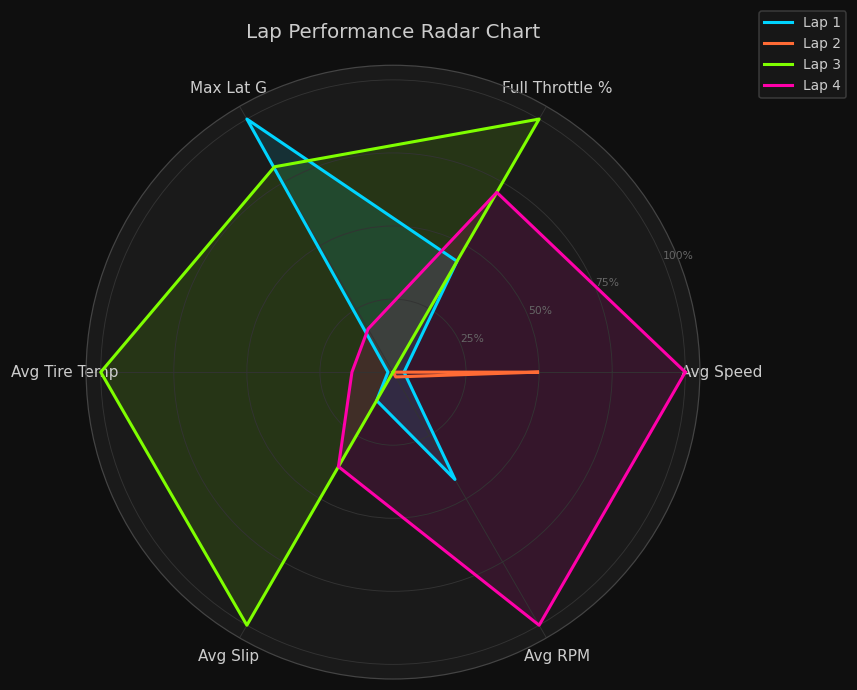

In [17]:
# Lap-level radar chart (normalize each metric to 0–1 for shape comparison)
radar_metrics = [
    'speed_avg_kmh', 'pct_full_throttle', 'max_lat_g',
    'tire_temp_avg_c', 'combined_slip_avg', 'rpm_avg',
]
radar_labels = ['Avg Speed', 'Full Throttle %', 'Max Lat G',
                'Avg Tire Temp', 'Avg Slip', 'Avg RPM']

# Normalise columns to 0–1 across laps
radar_df = lap_agg[['lap_number'] + radar_metrics].set_index('lap_number').copy()
radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min() + 1e-9)

N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a1a')

for lap in sorted(radar_norm.index):
    values = radar_norm.loc[lap].tolist() + radar_norm.loc[lap].tolist()[:1]
    ax.plot(angles, values, color=LAP_COLORS[lap], lw=2, label=f'Lap {lap}')
    ax.fill(angles, values, color=LAP_COLORS[lap], alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10, color='#cccccc')
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%','50%','75%','100%'], fontsize=7, color='#666666')
ax.yaxis.grid(True, color='#333333')
ax.xaxis.grid(True, color='#333333')
ax.set_title('Lap Performance Radar Chart', fontsize=13, pad=18, color='#cccccc')
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), fontsize=9)

plt.tight_layout()
plt.savefig('lap_radar.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## 12. Feature Summary

In [18]:
# Full list of engineered features added to df
original_cols = set(df_raw.columns)
new_cols = [c for c in df.columns if c not in original_cols]

print(f'Original columns : {len(original_cols)}')
print(f'Engineered features added: {len(new_cols)}')
print()
for c in sorted(new_cols):
    print(f'  {c}')

Original columns : 72
Engineered features added: 34

  best_lap_ref_time
  brake_norm
  combined_slip_avg
  corner_id
  delta_time_s
  dt_s
  front_slip_avg
  front_wheel_speed_avg
  g_lateral
  g_longitudinal
  lap_bin_200
  lap_dist_m
  lap_dist_pct
  power_kw
  rear_slip_avg
  rear_wheel_speed_avg
  roll_brake_max
  roll_lat_g_max
  roll_slip_mean
  roll_speed_mean
  roll_speed_std
  roll_throttle_mean
  speed_delta_kmh_s
  speed_kmh
  steer_norm
  throttle_norm
  tire_temp_avg
  tire_temp_deg_proxy
  tire_temp_fr_delta
  tire_temp_lr_delta
  track_section
  understeer_index
  wheel_lock_flag
  wheel_spin_index


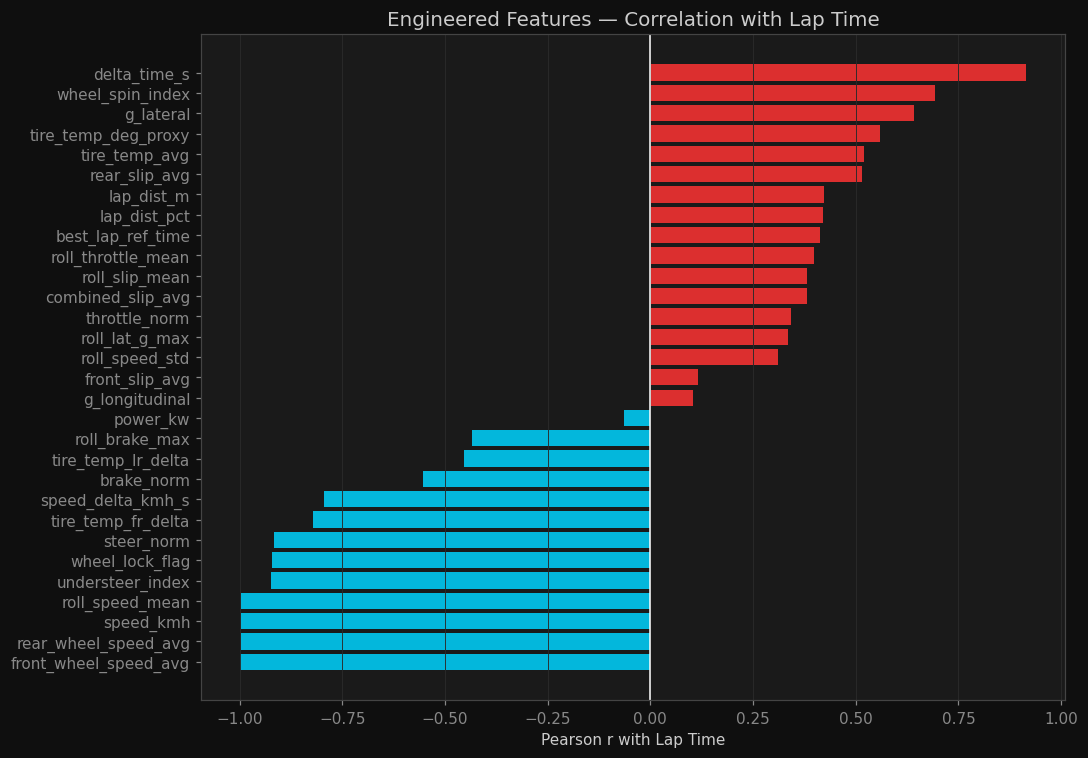

Top correlations with lap time:
front_wheel_speed_avg    0.999
rear_wheel_speed_avg     0.998
speed_kmh                0.997
roll_speed_mean          0.996
understeer_index         0.924
wheel_lock_flag          0.920
steer_norm               0.915
delta_time_s             0.914
Name: lap_time_s, dtype: float64


In [19]:
# Correlation of all new numeric features with lap_time_s (via lap-level join)
lap_time_map = lap_agg.set_index('lap_number')['lap_time_s']
df['lap_time_s'] = df['lap_number'].map(lap_time_map)

numeric_new = [c for c in new_cols
               if df[c].dtype in [np.float64, np.int64, int, float]
               and c not in ('dt_s', 'lap_bin_200', 'corner_id', 'lap_time_s')]

# Lap-mean of each feature correlated with lap_time_s
lap_means = df.groupby('lap_number')[numeric_new + ['lap_time_s']].mean()
corr_with_time = lap_means.corr()['lap_time_s'].drop('lap_time_s').sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = ['#ff3333' if v > 0 else '#00d4ff' for v in corr_with_time.values]
ax.barh(corr_with_time.index, corr_with_time.values, color=colors_bar, alpha=0.85)
ax.axvline(0, color='white', lw=1)
ax.set_xlabel('Pearson r with Lap Time')
ax.set_title('Engineered Features — Correlation with Lap Time', fontsize=13)
ax.grid(True, axis='x')
plt.tight_layout()
plt.savefig('feature_lap_correlation.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

print('Top correlations with lap time:')
print(corr_with_time.abs().sort_values(ascending=False).head(8).round(3))

## 13. Export

In [20]:
# ── Sample-level feature matrix ───────────────────────────────────────────────
export_cols = [
    # Identifiers
    'lap_number', 'lap_dist_m', 'lap_dist_pct', 'current_lap_time', 'current_race_time',
    # Position
    'position_x', 'position_y', 'position_z',
    # Normalized inputs
    'throttle_norm', 'brake_norm', 'steer_norm', 'gear',
    # Speed & engine
    'speed_kmh', 'speed_delta_kmh_s', 'current_engine_rpm', 'power_kw', 'torque', 'boost',
    # G-forces
    'g_lateral', 'g_longitudinal',
    # Tires
    'tire_temp_avg', 'tire_temp_fr_delta', 'tire_temp_lr_delta', 'tire_temp_deg_proxy',
    'combined_slip_avg', 'understeer_index', 'wheel_spin_index', 'wheel_lock_flag',
    # Suspension
    'normalized_suspension_travel_front_left', 'normalized_suspension_travel_front_right',
    'normalized_suspension_travel_rear_left',  'normalized_suspension_travel_rear_right',
    # Track classification
    'track_section', 'corner_id',
    # Rolling features
    'roll_speed_mean', 'roll_speed_std', 'roll_throttle_mean',
    'roll_brake_max', 'roll_lat_g_max', 'roll_slip_mean',
    # Delta time
    'delta_time_s',
    # Fuel
    'fuel',
]

df_export = df[export_cols].copy()
df_export.to_parquet('features_engineered.parquet', index=False)
print(f'features_engineered.parquet saved — {df_export.shape[0]:,} rows × {df_export.shape[1]} columns')

# ── Lap-level features ────────────────────────────────────────────────────────
lap_agg.to_csv('features_per_lap.csv', index=False)
print(f'features_per_lap.csv saved — {lap_agg.shape[0]} rows × {lap_agg.shape[1]} columns')

# ── Corner-level features ─────────────────────────────────────────────────────
df_corners.to_csv('features_per_corner.csv', index=False)
print(f'features_per_corner.csv saved — {df_corners.shape[0]} rows × {df_corners.shape[1]} columns')

features_engineered.parquet saved — 75,090 rows × 42 columns
features_per_lap.csv saved — 4 rows × 29 columns
features_per_corner.csv saved — 56 rows × 11 columns


## 14. Feature Engineering Summary

### Engineered Features

| Group | Feature | Description |
|---|---|---|
| Inputs | `throttle_norm`, `brake_norm`, `steer_norm` | Inputs normalized to [0,1] / [-1,1] |
| Track | `lap_dist_m`, `lap_dist_pct`, `lap_bin_200` | Distance from lap start and normalized position |
| Section | `track_section` | STRAIGHT / BRAKING / CORNER / ACCELERATION |
| Corner | `corner_id` | Integer ID per corner window (−1 = not in corner) |
| Dynamics | `speed_delta_kmh_s` | Rate of speed change (km/h per second) |
| Dynamics | `understeer_index` | Front – rear slip angle (positive = understeer) |
| Dynamics | `wheel_spin_index` | (Rear − Front) wheel speed / Front speed |
| Dynamics | `wheel_lock_flag` | Binary: braking + negative wheel spin index |
| Dynamics | `combined_slip_avg` | Mean combined slip across all 4 tires |
| Tires | `tire_temp_avg` | Mean temperature across all 4 tires |
| Tires | `tire_temp_fr_delta` | Front – rear temperature imbalance |
| Tires | `tire_temp_lr_delta` | Left – right temperature imbalance |
| Tires | `tire_temp_deg_proxy` | Tire temp rise since lap start |
| Rolling | `roll_speed_mean/std` | 1-second rolling statistics on speed |
| Rolling | `roll_throttle_mean`, `roll_brake_max`, `roll_lat_g_max`, `roll_slip_mean` | 1-second rolling statistics |
| Delta | `delta_time_s` | Time gap vs best lap at same track position |

### Output Files

| File | Rows | Cols | Use |
|---|---|---|---|
| `features_engineered.parquet` | 75,090 | 40 | Sample-level modeling input |
| `features_per_lap.csv` | 4 | 27 | Lap-level analysis / regression |
| `features_per_corner.csv` | ~44 | 11 | Corner-level analysis |

### Next Steps
- `03_modeling.ipynb` — use `features_engineered.parquet` to train predictive models  
  - Predict `delta_time_s` from vehicle dynamics
  - Classify `track_section` from sensor inputs
  - Cluster corners by difficulty metrics